# Laboratorul 3

Rezolvați exercițiile de mai jos în celulele care v-au fost puse la dispoziție. La final, rulați tot notebook-ul și asigurați-vă că nu aveți erori. Salvați fișierul și încărcați-l în assignment-ul de Teams corespunzător grupei voastre.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import sounddevice

## Exercițiul 1

Generați un semnal sinusoidal folosind funcția sinus (`np.sin`) cu o amplitudine, frecvență și fază aleasă de voi. Generați apoi un semnal folosind funcția cosinus (`np.cos`) astfel încât, pe orizontul de timp ales, acesta să fie identic cu semnalul sinus. Verificați afișându-le grafic în două subplot-uri diferite.

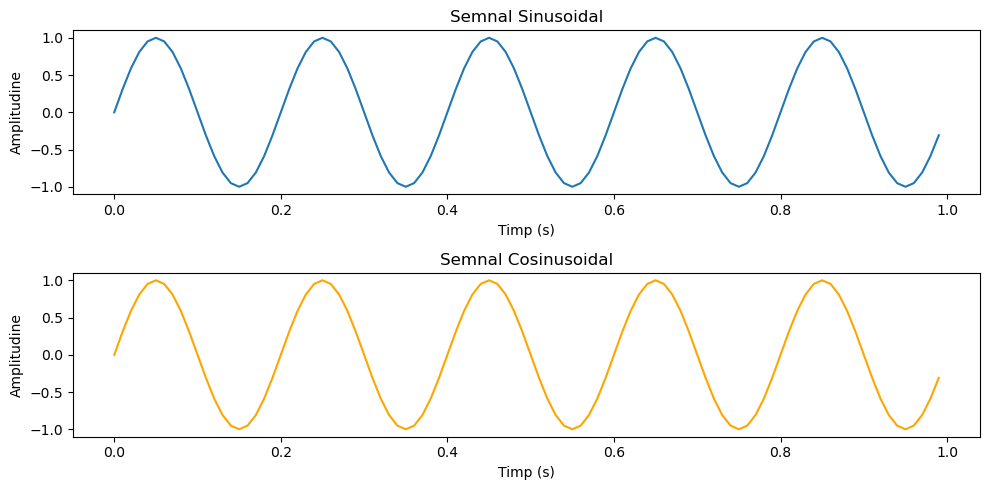

In [ ]:
amplitudine = 1
frecventa = 5
faza = 0 
durata = 1  
fs = 100  

t = np.linspace(0, durata, int(fs * durata), endpoint=False)

sin_wave = amplitudine * np.sin(2 * np.pi * frecventa * t + faza)
cos_wave = amplitudine * np.cos(2 * np.pi * frecventa * t + faza - np.pi / 2)

plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(t, sin_wave)
plt.title("Semnal Sinusoidal")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")

plt.subplot(2, 1, 2)
plt.plot(t, cos_wave, color='orange')
plt.title("Semnal Cosinusoidal")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")

plt.tight_layout()
plt.show()


## Exercițiul 2

Generați un semnal sinusoidal de amplitudine egală cu 1 și cu o frecvență aleasă de voi. Încercați 4 valori diferite pentru fază. Afișați toate semnalele pe același grafic.

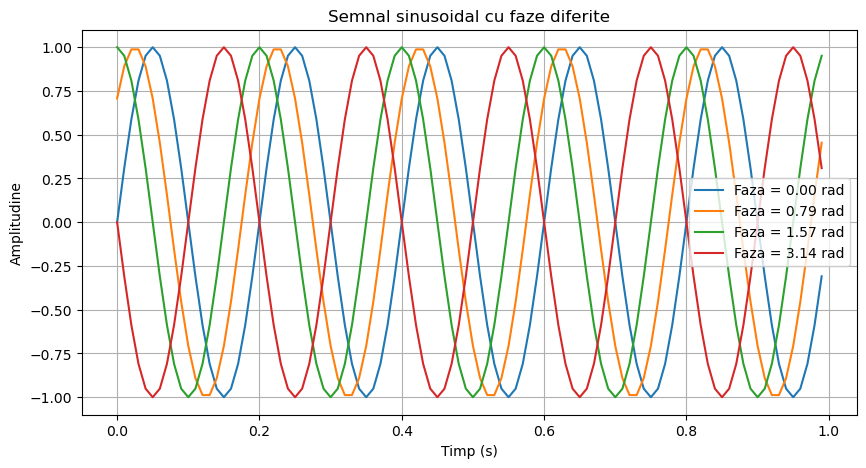

In [ ]:
amplitudine = 1
frecventa = 5  
fs = 100
durata = 1  
t = np.linspace(0, durata, int(fs * durata), endpoint=False)

phases = [0, np.pi/4, np.pi/2, np.pi]

plt.figure(figsize=(10, 5))
for faza in phases:
    sin_wave = amplitudine * np.sin(2 * np.pi * frecventa * t + faza)
    plt.plot(t, sin_wave, label=f'Faza = {faza:.2f} rad')

plt.title("Semnal sinusoidal cu faze diferite")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")
plt.legend()
plt.grid()
plt.show()


## Exercițiul 3

Generați două semnale cu forme de undă diferite (ex. unul sinusoidal, celălalt sawtooth) pe același orizont de timp și adunațile eșantioanele. Afișați grafic cele două semnale inițiale și suma lor, fiecare în câte un subplot.

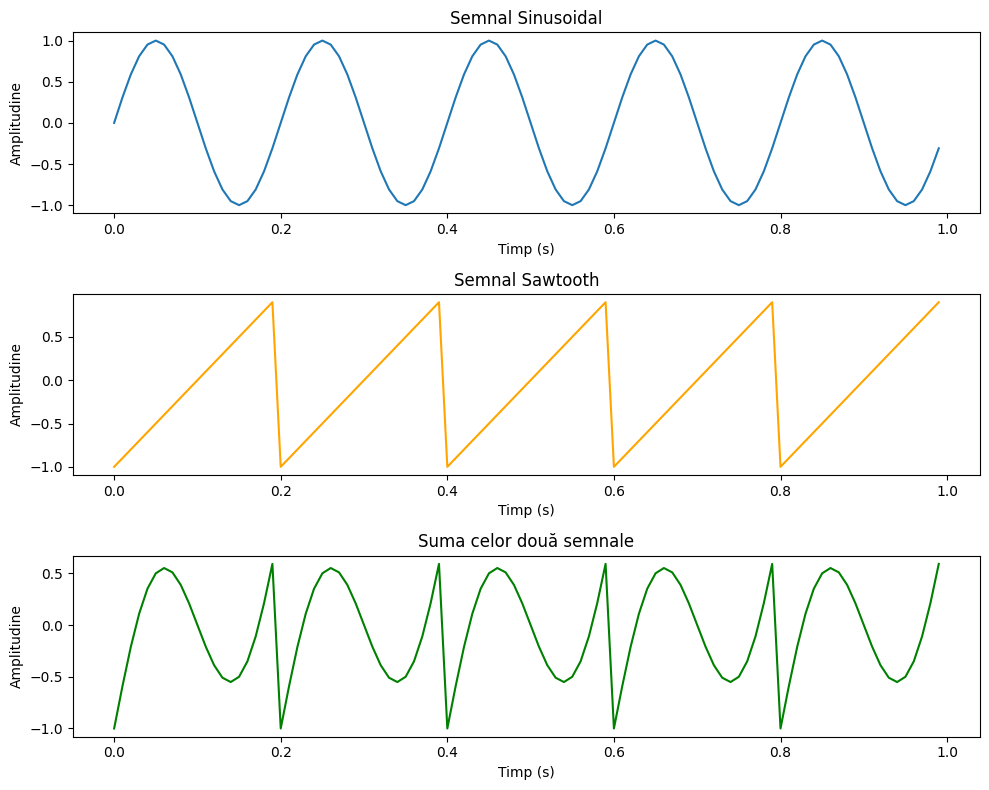

In [ ]:
from scipy.signal import sawtooth

frecventa = 5 
fs = 100  
durata = 1 
t = np.linspace(0, durata, int(fs * durata), endpoint=False)

sin_wave = np.sin(2 * np.pi * frecventa * t)
saw_wave = sawtooth(2 * np.pi * frecventa * t)
suma_wave = sin_wave + saw_wave

plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(t, sin_wave)
plt.title("Semnal Sinusoidal")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")

plt.subplot(3, 1, 2)
plt.plot(t, saw_wave, color='orange')
plt.title("Semnal Sawtooth")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")

plt.subplot(3, 1, 3)
plt.plot(t, suma_wave, color='green')
plt.title("Suma celor două semnale")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")

plt.tight_layout()
plt.show()


## Exercițiul 4

Generați două semnale cu aceeași formă de undă, dar de frecvențe diferite, și concatenați-le (puneți-le unul după celălalt în același vector). Redați audio rezultatul și notați ce observați.

**Observație:** Intervalul de frecvențe pe care îl poate percepe urechea umană este aproximativ 40&ndash;20000 Hz. Semnalele voastre ar trebui să aibă frecvențele fundamentale în acest interval dacă vreți să le puteți auzi. Frecvența de eșantionare ar trebui să fie 44100 Hz.

In [ ]:

frecventa1 = 440  
frecventa2 = 880  
fs = 44100  
durata = 1  

t = np.linspace(0, durata, int(fs * durata), endpoint=False)

signal1 = np.sin(2 * np.pi * frecventa1 * t)
signal2 = np.sin(2 * np.pi * frecventa2 * t)

concat_signal = np.concatenate((signal1, signal2))

sounddevice.play(concat_signal, fs)
sounddevice.wait()  



## Exercițiul 5

Generați un semnal sinusoidal de frecvență 200 Hz, eșantionat la o frecvență de 500 Hz pe un interval de timp ales de voi (dar suficient de mic cât să puteți distinge oscilațiile). Decimați-l la 1/4 din frecvența inițială (păstrați doar al 4-lea fiecare element din vector).

1. Afișați grafic semnalul inițial și cel decimat și comentați diferențele.

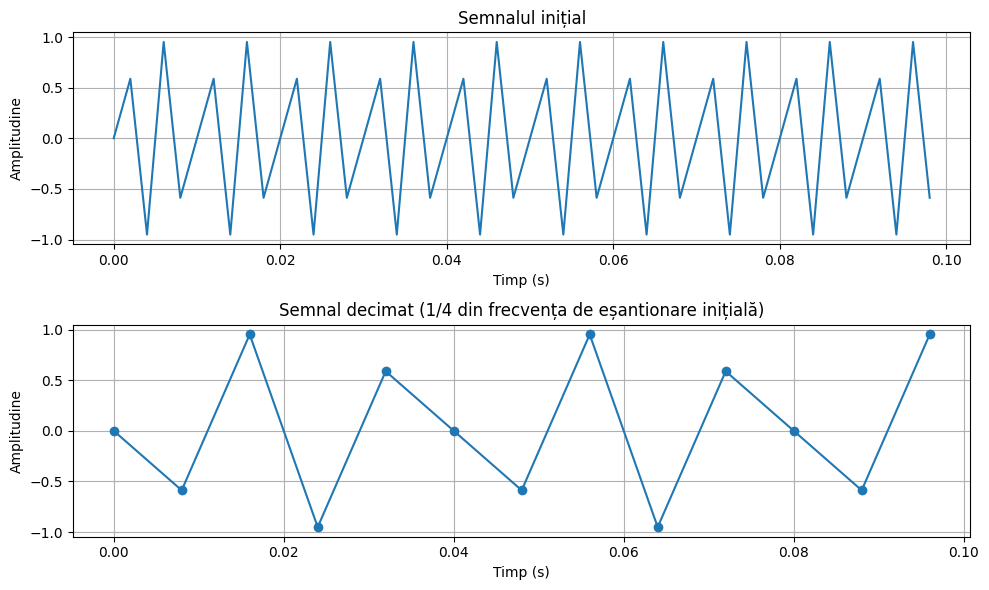

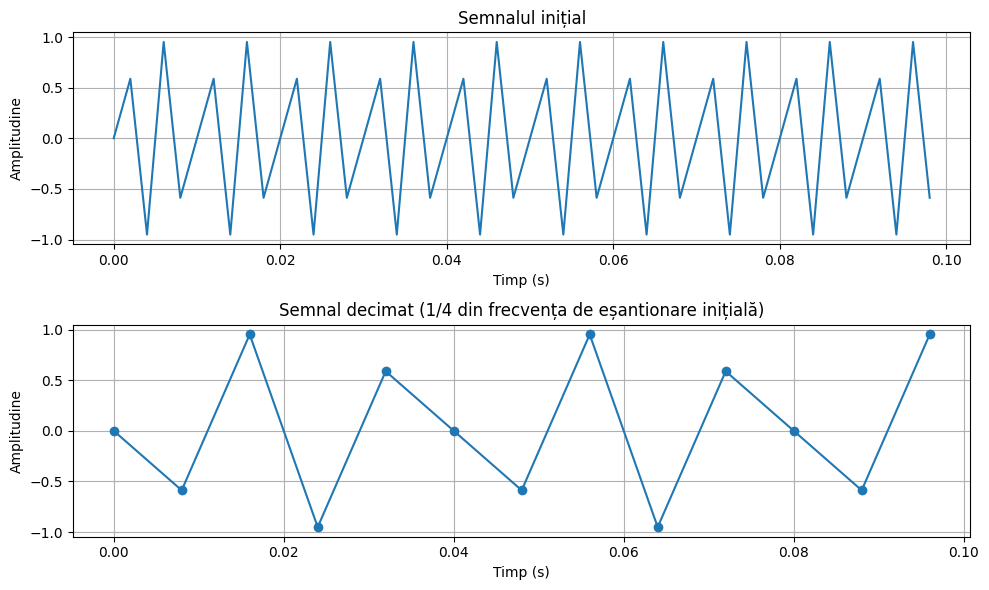

In [ ]:

frecventa = 200  
fs = 500  
durata = 0.1  
t = np.linspace(0, durata, int(fs * durata), endpoint=False)

signal = np.sin(2 * np.pi * frecventa * t)

signal_decimated = signal[::4]  
t_decimated = t[::4]  

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal, label="Semnal original")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")
plt.title("Semnalul inițial")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t_decimated, signal_decimated, 'o-', label="Semnal decimat")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")
plt.title("Semnal decimat (1/4 din frecvența de eșantionare inițială)")
plt.grid()

plt.tight_layout()
plt.show()

frecventa = 200  
fs = 500  
durata = 0.1 
t = np.linspace(0, durata, int(fs * durata), endpoint=False)

signal = np.sin(2 * np.pi * frecventa * t)

signal_decimated = signal[::4]  
t_decimated = t[::4]  

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal, label="Semnal original")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")
plt.title("Semnalul inițial")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t_decimated, signal_decimated, 'o-', label="Semnal decimat")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")
plt.title("Semnal decimat (1/4 din frecvența de eșantionare inițială)")
plt.grid()

plt.tight_layout()
plt.show()


2. Repetați decimarea (tot la 1/4 din frecvența inițială) pornind acum de la al doilea sau de la al treilea element din vector. Ce observați? Este decimarea invariantă în timp?

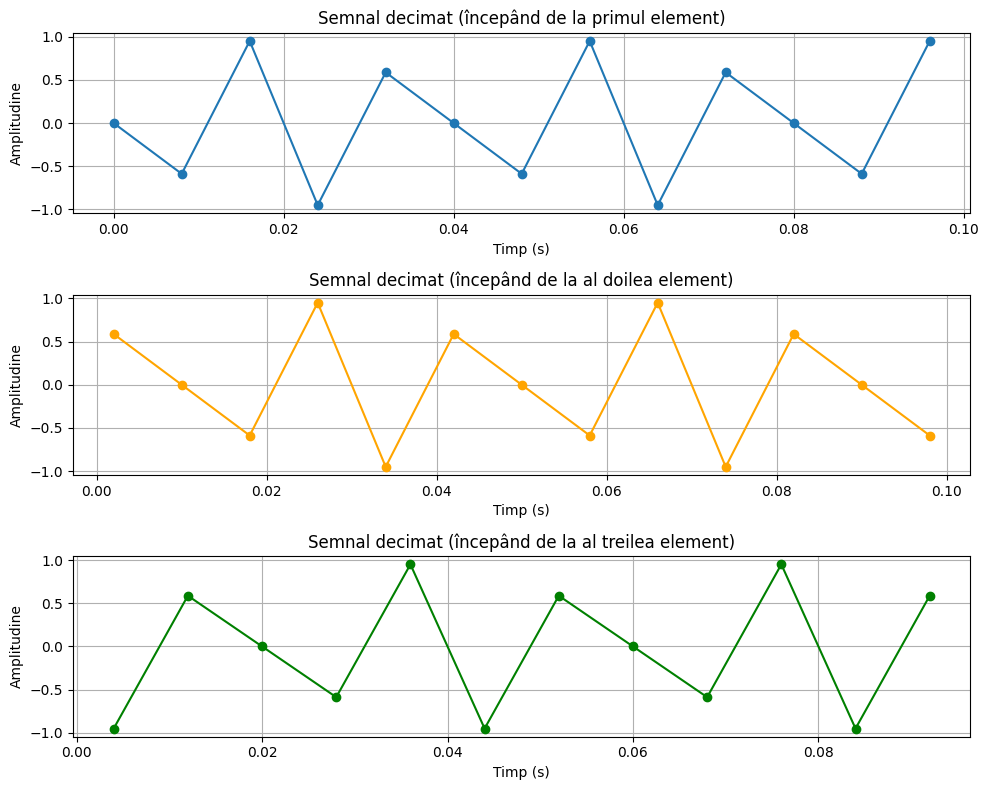

In [ ]:
signal_decimated_2 = signal[1::4] 
signal_decimated_3 = signal[2::4] 

plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(t_decimated, signal_decimated, 'o-', label="Decimare de la primul element")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")
plt.title("Semnal decimat (începând de la primul element)")
plt.grid()

plt.subplot(3, 1, 2)
plt.plot(t[1::4], signal_decimated_2, 'o-', label="Decimare de la al doilea element", color="orange")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")
plt.title("Semnal decimat (începând de la al doilea element)")
plt.grid()

plt.subplot(3, 1, 3)
plt.plot(t[2::4], signal_decimated_3, 'o-', label="Decimare de la al treilea element", color="green")
plt.xlabel("Timp (s)")
plt.ylabel("Amplitudine")
plt.title("Semnal decimat (începând de la al treilea element)")
plt.grid()

plt.tight_layout()
plt.show()



## Exercițiul 6

În practică se operează des cu următoarea aproximare: pentru valori mici ale lui $\alpha$, $\sin(\alpha) \approx \alpha$. Verificați dacă această aproximare este bună, reprezentând grafic cele două curbe ($f (x) = x$
și $f (x) = \sin(x)$) pentru valori în intervalul $[-\pi/2, \pi/2]$.

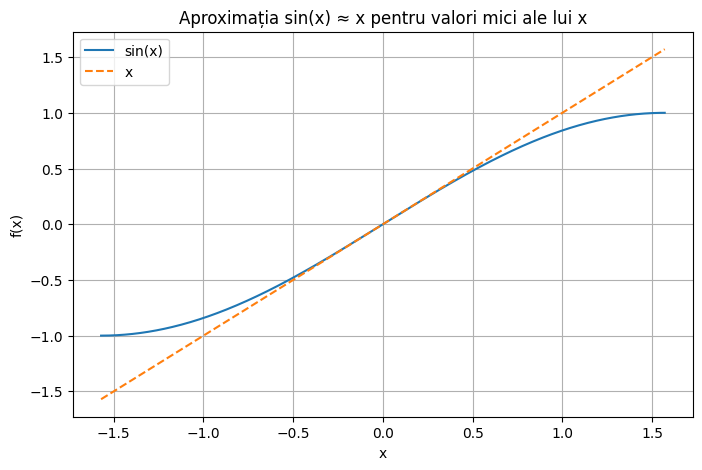

In [ ]:
x = np.linspace(-np.pi / 2, np.pi / 2, 500)

y_sin = np.sin(x)
y_x = x

plt.figure(figsize=(8, 5))
plt.plot(x, y_sin, label="sin(x)")
plt.plot(x, y_x, label="x", linestyle='--')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Aproximația sin(x) ≈ x pentru valori mici ale lui x")
plt.legend()
plt.grid()
plt.show()
